In [5]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
# lets load the data as a pandas DataFrame
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [6]:
df.target.value_counts()

# here 0 is setosa, 1 is versicolor and 2 is virginica

def get_species_name(target):
    if target == 0:
        return 'setosa'
    elif target == 1:
        return 'versicolor'
    else:
        return 'virginica'
    
df['species'] = df['target'].apply(get_species_name)

# lets do rename of columns
df.rename(columns={'sepal length (cm)': 'sepal_length_cm',
                   'sepal width (cm)': 'sepal_width_cm',
                   'petal length (cm)': 'petal_length_cm',
                   'petal width (cm)': 'petal_width_cm'}, inplace=True)

df.head(2)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa


In [7]:
# how many columns and rows are there in the dataset
df.shape
# info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   target           150 non-null    int64  
 5   species          150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
# 1 D analysis
df['sepal_length_cm'].describe()

# Here std mean  is standard deviation
# What do you mean by std?
# Standard deviation (std) is a measure of the
#  amount of variation or dispersion in a set of values. 
# A low standard deviation indicates that the values tend
# to be close to the mean (average) of the set, 
# while a high standard deviation indicates that the values are spread out over a wider range.

# what do you mean by percentiles?
# Percentiles are measures that indicate the relative standing of a value within a dataset.
#  They divide a dataset into 100 equal parts,
#  allowing us to understand how a particular value compares to the rest of the data.
# Eg. 1.2 is 25th percentile means 25% of data points are below 1.2
# and 75% of data points are above 1.2

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: sepal_length_cm, dtype: float64

1D Analysis for column: petal_length_cm
----------------------------------------
Descriptive Statistics:
count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length_cm, dtype: float64




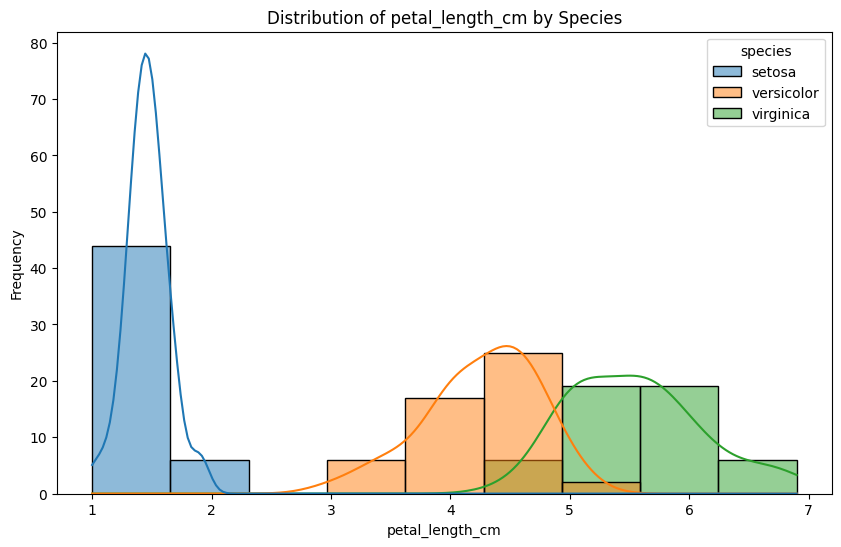

In [9]:
# lets 1 d plot - distribution with repect to species
import matplotlib.pyplot as plt
import seaborn as sns
# plt.figure(figsize=(10, 6))
# sns.histplot(data=df, x='petal_width_cm', hue='species', kde=True)
# plt.title('Distribution of Sepal Width by Species')
# plt.xlabel('Sepal Width (cm)')
# plt.ylabel('Frequency')
# plt.show()


# lets create the reusable function for 1 d analysis
def one_d_analysis(data, column):
    print(f"1D Analysis for column: {column}")
    print("-" * 40)
    print("Descriptive Statistics:")
    print(data[column].describe())
    print("\n")
    
    plt.figure(figsize=(10, 6))
    sns.histplot(data=data, x=column, hue='species', kde=True)
    plt.title(f'Distribution of {column} by Species')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# lets test the function
one_d_analysis(df, 'petal_length_cm')

Boxplot Analysis for petal_width_cm by species
----------------------------------------


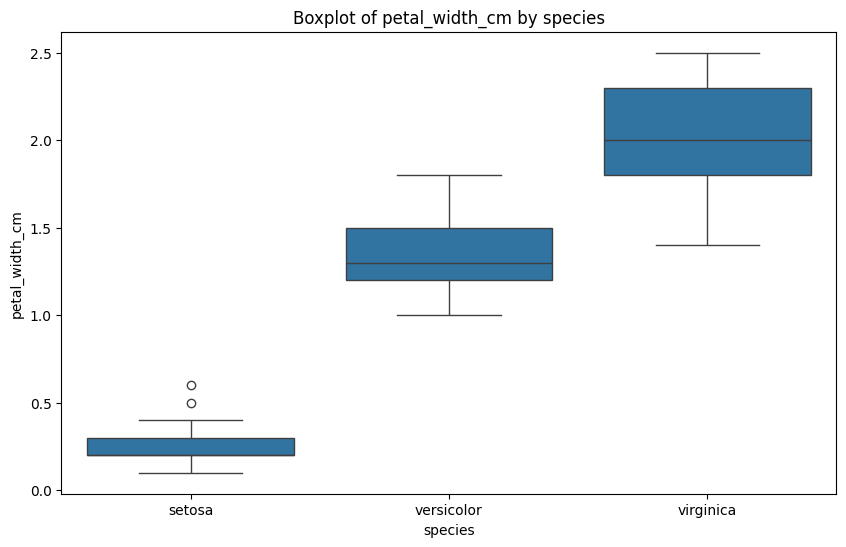

In [10]:
# Boxplot - 
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='species', y='sepal_length_cm', data=df)  
# plt.title('Boxplot of Sepal Length by Species')
# plt.xlabel('Species')
# plt.ylabel('Sepal Length (cm)')
# plt.show()

# lets wrap it in a function
def boxplot_analysis(data, x_column, y_column):
    print(f"Boxplot Analysis for {y_column} by {x_column}")
    print("-" * 40)
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=x_column, y=y_column, data=data)  
    plt.title(f'Boxplot of {y_column} by {x_column}')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.show()

# lets test the function
boxplot_analysis(df, 'species', 'petal_width_cm')


Scatter Plot Analysis for petal_width_cm vs petal_length_cm colored by species
----------------------------------------


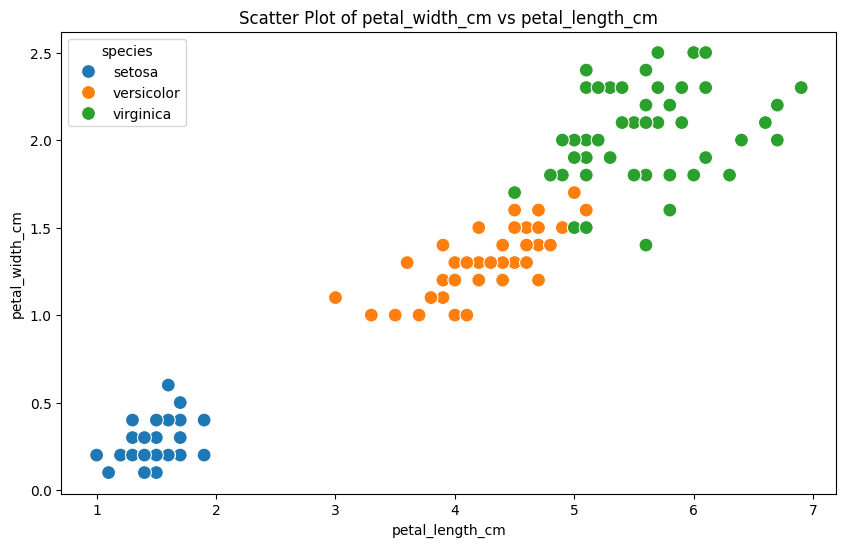

In [11]:
# scatter plot : 2D analysis
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df, x='sepal_length_cm', y='sepal_width_cm', hue='species', s=100)
# plt.title('Scatter Plot of Sepal Length vs Sepal Width')
# plt.xlabel('Sepal Length (cm)')
# plt.ylabel('Sepal Width (cm)')
# plt.show()


# lets wrap it in a function
def scatter_plot_analysis(data, x_column, y_column, hue_column):    
    print(f"Scatter Plot Analysis for {y_column} vs {x_column} colored by {hue_column}")
    print("-" * 40)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=x_column, y=y_column, hue=hue_column, s=100)
    plt.title(f'Scatter Plot of {y_column} vs {x_column}')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.show()

# lets test the function
scatter_plot_analysis(df, 'petal_length_cm', 'petal_width_cm', 'species')

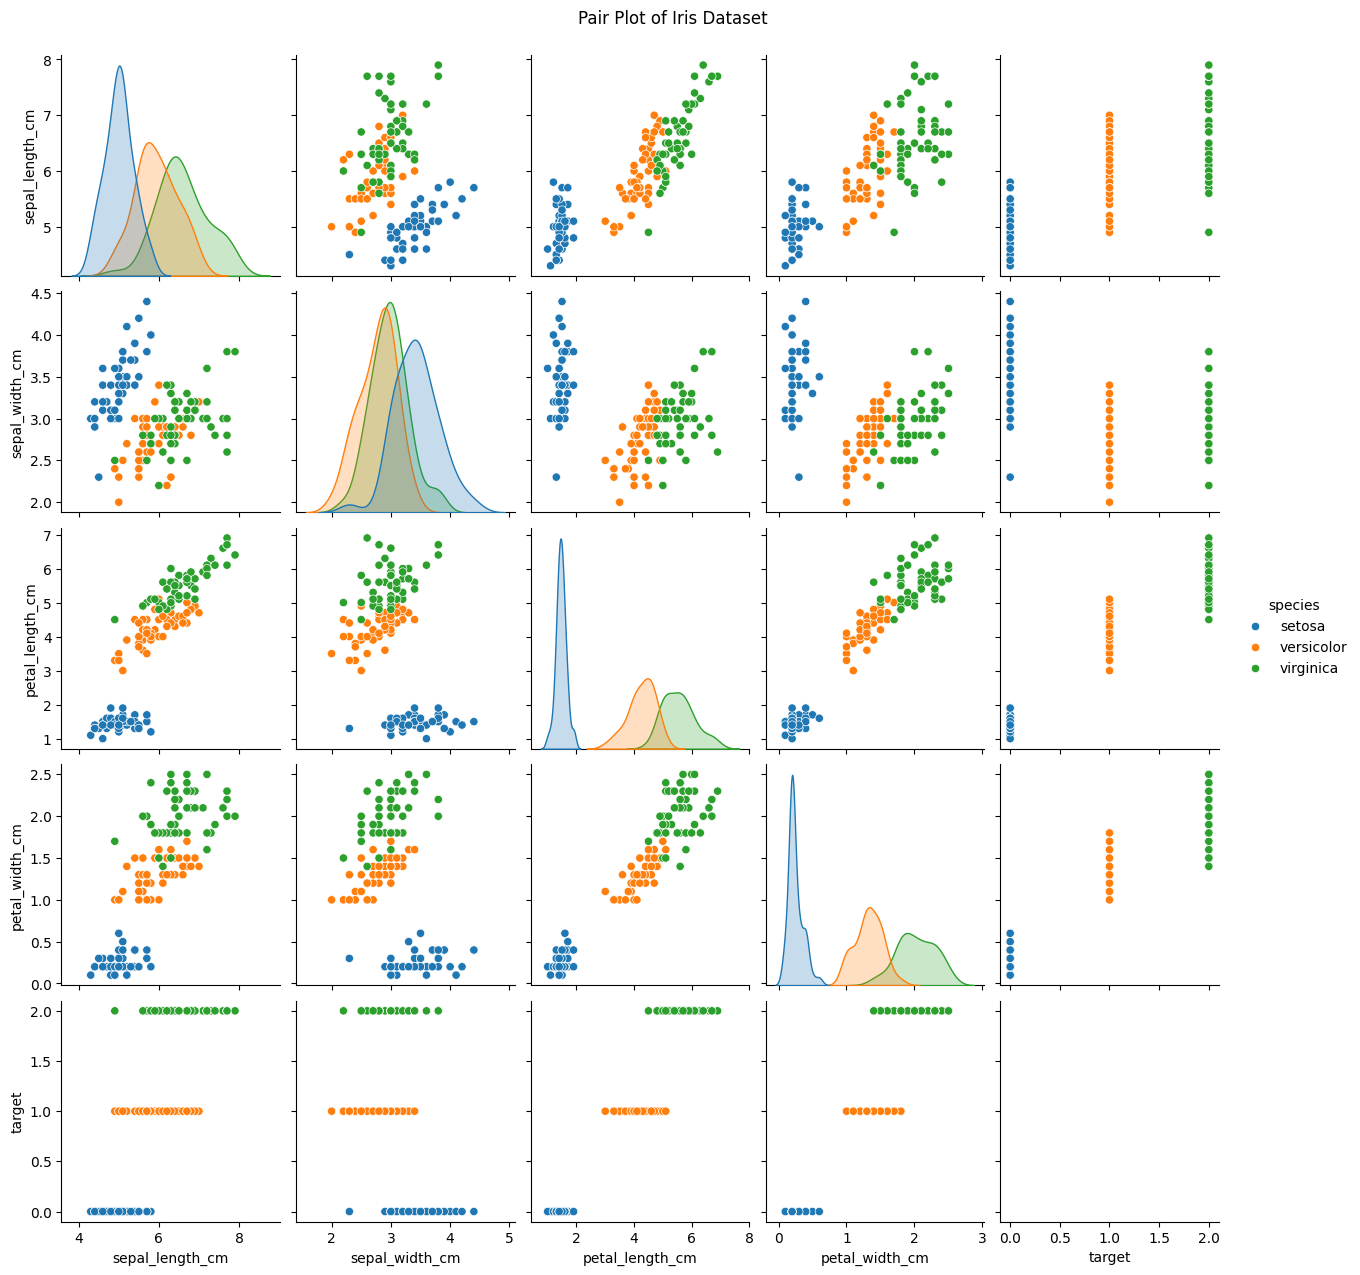

In [12]:
# pair plot
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pair Plot of Iris Dataset', y=1.02)
plt.show()


Text(0, 0.5, 'Density')

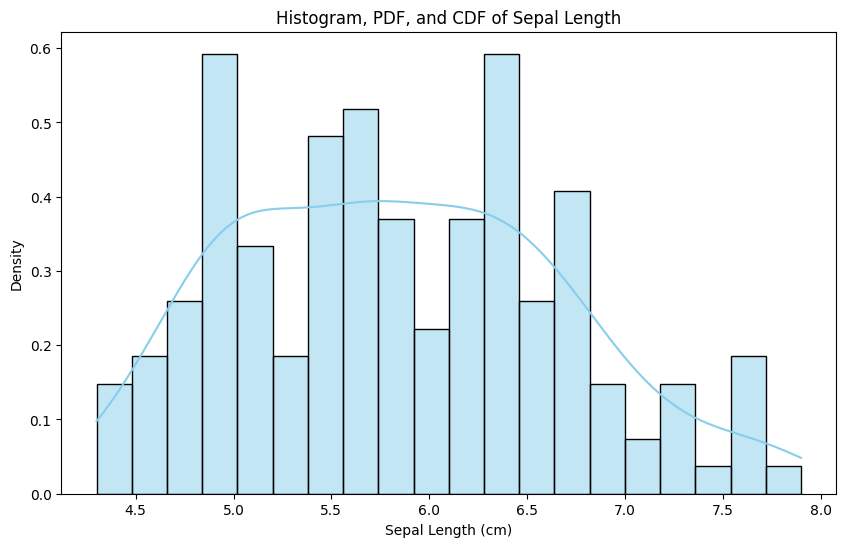

In [13]:
# Histogram, PDF, CDF
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='sepal_length_cm', bins=20, kde=True, stat='density', color='skyblue', edgecolor='black')
plt.title('Histogram, PDF, and CDF of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')   


/var/folders/fq/kr6gv5l17pd4j572n0_n3f2c0000gn/T/ipykernel_4909/2537566347.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(data=df, x='sepal_length_cm', palette='Set2')


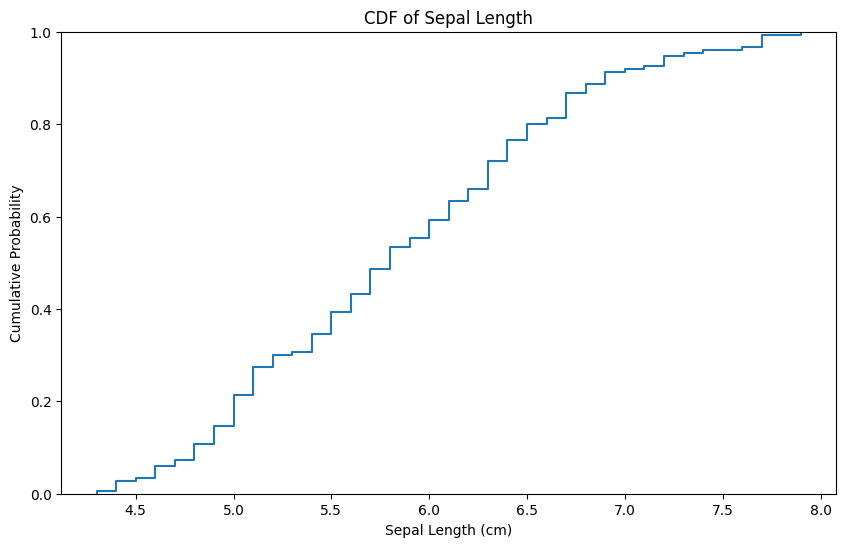

In [16]:
# Lets only plot CDF of sepal length only
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df, x='sepal_length_cm', palette='Set2')
plt.title('CDF of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Cumulative Probability')
plt.show()

# how to interpret CDF plot?
# The CDF plot shows the cumulative probability distribution of sepal lengths in the dataset. 
# For example, if you look at a sepal length of 6 cm on the x-axis and find the corresponding value on the y-axis, 
# it indicates the proportion of iris flowers with sepal lengths less than or equal to 6 cm. 
# If the y-value is 0.7, it means that 70% of the flowers have sepal lengths of 6 cm or shorter. 
# The steepness of the curve indicates how concentrated the sepal lengths are around certain values; 
# a steeper curve suggests that many flowers have similar sepal lengths, while a flatter curve indicates a wider spread of sepal lengths in the dataset.
plt.show()

/var/folders/fq/kr6gv5l17pd4j572n0_n3f2c0000gn/T/ipykernel_4909/4020437482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y='sepal_width_cm', data=df, palette='Set3')


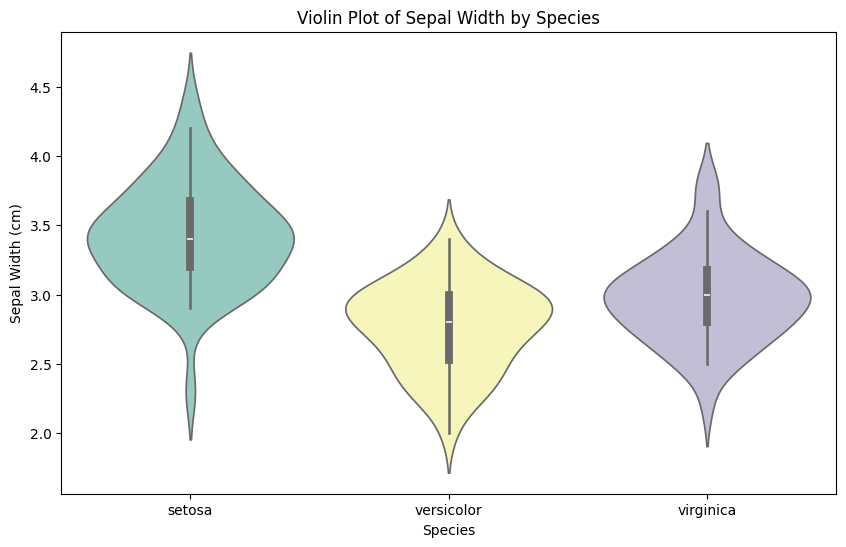

In [17]:
# volian plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='species', y='sepal_width_cm', data=df, palette='Set3')
plt.title('Violin Plot of Sepal Width by Species')
plt.xlabel('Species')
plt.ylabel('Sepal Width (cm)')
plt.show()

In [18]:
# lets build simple Rule based Classifier
def rule_based_classifier(row):
    if row['petal_length_cm'] < 2.5:
        return 'setosa'
    elif row['petal_length_cm'] < 5.0:
        return 'versicolor'
    else:
        return 'virginica'
    

df['predicted_species'] = df.apply(rule_based_classifier, axis=1)
df[['species', 'predicted_species']].head(10)

,species,predicted_species
0,setosa,setosa
1,setosa,setosa
2,setosa,setosa
3,setosa,setosa
4,setosa,setosa
5,setosa,setosa
6,setosa,setosa
7,setosa,setosa
8,setosa,setosa
9,setosa,setosa
